#### **PROBLEM STATEMENT**

**The goal of this project is to analyze Diwali sales data to understand
customer purchasing behavior based on gender, age group, state,
and product categories.**

#### **IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### **LOADING DATASET**

In [3]:
df = pd.read_csv('Diwali Sales Data.csv', encoding='latin-1')
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


#### **DATASET OVERVIEW**

In [6]:
df.shape

(11251, 15)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [8]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


#### **DATA CLEANING**

1.Remove Unwanted Columns

In [9]:
df.drop(['Status','unnamed1'],axis = 1, inplace = True)

2.Check Null Values

In [12]:
df.isnull().sum()

,0
User_ID,0
Cust_name,0
Product_ID,0
Gender,0
Age Group,0
Age,0
Marital_Status,0
State,0
Zone,0
Occupation,0


3.Remove Rows with Missing Values

In [14]:
df.dropna(inplace=True)

4.Reset Index After Dropping Rows

In [15]:
df.reset_index(drop=True, inplace=True)

5.Change Data Type

In [16]:
df['Amount'] = df['Amount'].astype('int')

#### **EDA(EXPLORATORY DATA ANALYSIS)**

**1.DATA ANALYSIS**

1.Gender Frequency Analysis

In [21]:
df['Gender'].value_counts()

,count
Gender,
F,7832
M,3407


2.Filter Female Customers

In [23]:
df[df['Gender'] == 'F']

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841
8,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11229,1003032,Matthias,P00058042,F,26-35,33,0,Delhi,Central,Hospitality,Office,3,384
11230,1004344,Hildebrand,P00185442,F,26-35,27,1,Delhi,Central,Healthcare,Office,2,382
11233,1004140,Bertelson,P00057442,F,26-35,31,1,Delhi,Central,Aviation,Office,2,381
11236,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213


3.Total Spending by Female Customers

In [26]:
df[df['Gender'] == 'F']['Amount'].sum()

np.int64(74335853)

4.Sort Transactions by Amount

In [27]:
df.sort_values(by='Amount', ascending=False)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11234,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370
11235,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367
11236,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213
11237,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206


5.Top 10 Highest Purchases

In [28]:
df.sort_values(by='Amount', ascending=False).head(10)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841
7,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809
8,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799
9,1003829,Harshita,P00200842,M,26-35,34,0,Delhi,Central,Banking,Auto,1,23770


6.Unique States

In [29]:
df['State'].unique()

array(['Maharashtra', 'Andhra\xa0Pradesh', 'Uttar Pradesh', 'Karnataka',
       'Gujarat', 'Himachal Pradesh', 'Delhi', 'Jharkhand', 'Kerala',
       'Haryana', 'Madhya Pradesh', 'Bihar', 'Rajasthan', 'Uttarakhand',
       'Telangana', 'Punjab'], dtype=object)

7.Number of Unique States

In [30]:
df['State'].nunique()

16

8.State-wise Sales

In [37]:
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False)
state_sales

,Amount
State,
Uttar Pradesh,19374968
Maharashtra,14427543
Karnataka,13523540
Delhi,11603818
Madhya Pradesh,8101142
Andhra Pradesh,8037146
Himachal Pradesh,4963368
Haryana,4220175
Bihar,4022757


9.Pivot Table Analysis

In [33]:
pd.pivot_table(df, values='Amount', index='Gender', columns='Marital_Status', aggfunc='sum')

Marital_Status,0,1
Gender,,
F,43786646,30549207
M,18338738,13574538


**2.VISUALIZATION**

1.Gender Distribution

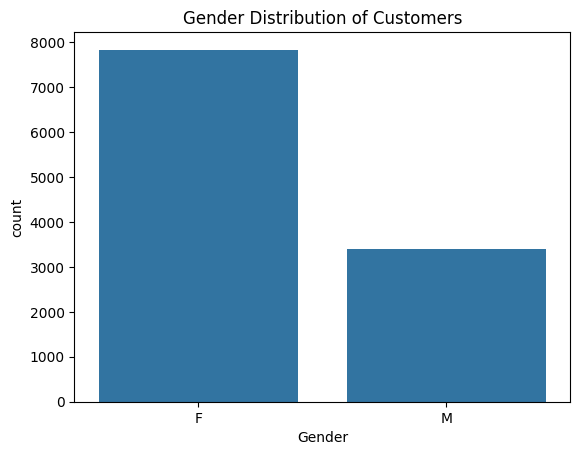

In [34]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution of Customers")
plt.show()

2.Age Group vs Gender

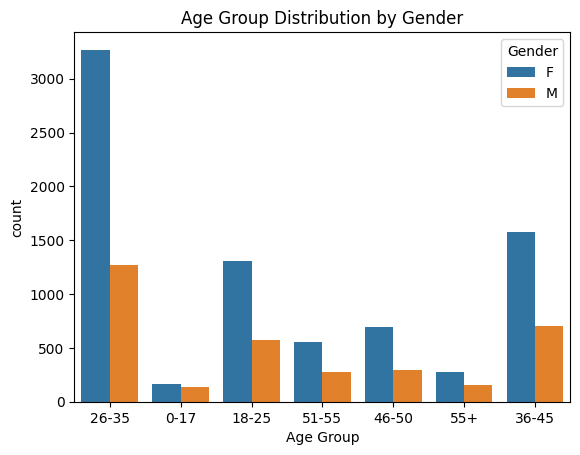

In [35]:
sns.countplot(x='Age Group', hue='Gender', data=df)
plt.title("Age Group Distribution by Gender")
plt.show()

3.Top States by Sales

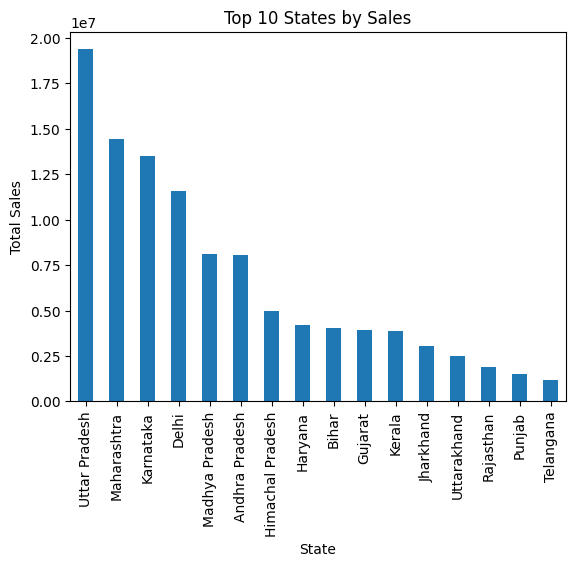

In [38]:
state_sales.plot(kind='bar')
plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.show()

4.Total Sales by Gender

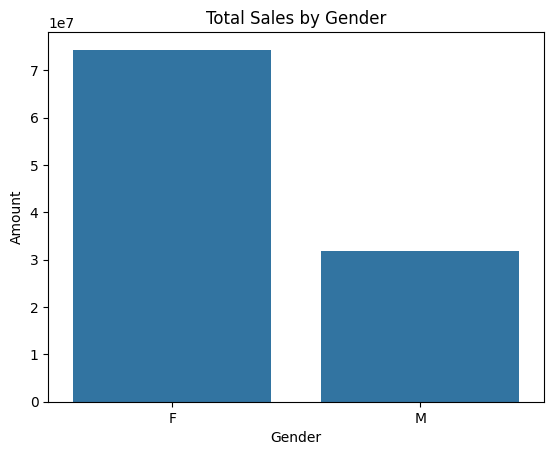

In [39]:
sales_gen = df.groupby('Gender')['Amount'].sum().reset_index()

sns.barplot(x='Gender', y='Amount', data=sales_gen)
plt.title("Total Sales by Gender")
plt.show()

5.Product Category Sales

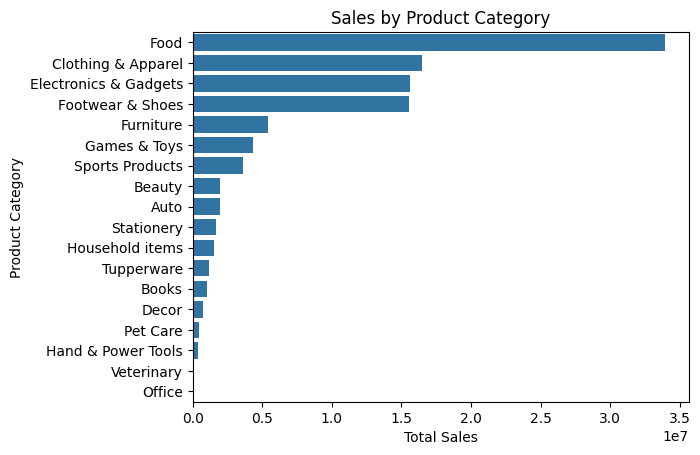

In [40]:
category_sales = df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False)

sns.barplot(x=category_sales.values, y=category_sales.index)
plt.title("Sales by Product Category")
plt.xlabel("Total Sales")
plt.ylabel("Product Category")
plt.show()

#### **INSIGHTS**

1. Female customers contribute more to total sales than male customers.
2. The 26–35 age group has the highest number of buyers.
3. Uttar Pradesh, Maharashtra, and Karnataka generate the highest sales.
4. Food and clothing categories have the highest demand.